# CS/INFO 5304 Phase 4: Final Analysis
**Team:** Zane Mroue (zsm7), Grace Myers (gm586), Samy Lokanandi (sl3539), Ali Hasan (ah2434)

GITHUB: https://github.com/sl3539-svg/Data-Science-Project

## 1. Introduction

### Does Yelp Review Language Correlate to Neighborhood Rent Growth?

### Research Questions

Our project began with two broad questions from Phase 1 and 2:

Are the types of businesses listed on Yelp, particularly those associated with upscale or trendy dining culture such as wine bars, specialty coffee shops, and brunch spots, correlate with rent increases at the ZIP code level?

Does the language people use in Yelp reviews, specifically the frequency of gentrification-associated terms like "aesthetic," "vibe," and "artisanal," correlate with future rent appreciation?

Based on TA feedback and our Phase 2 exploratory analysis, we refined these into three more precise questions for Phase 4:

1. Does a PCA-weighted gentrification language score predict next-year rent growth at the ZIP code level after controlling for baseline rent, review volume, metro, and year?
2. Does the share of gentrification-associated food businesses in a ZIP code predict next-year rent growth, and does this relationship differ significantly across our five metros?
3. Do ZIP codes in the top quartile of gentrification language intensity show meaningfully higher future rent growth than those in the bottom quartile?

The shift from equal-weighted keyword averaging to PCA was motivated by a limitation we identified in Phase 2: individual keywords like "brunch" and "hipster" were negatively correlated with rent growth while others like "charcuterie" were positively correlated, meaning the composite score was averaging out signal rather than amplifying it. We also shifted away from using Yelp's price ratings as a business composition measure based on TA feedback, since category labels like Wine Bars or Gastropubs are a more direct and reliable way to identify the types of businesses typically associated with neighborhood change.

### Background

Gentrification is difficult to detect in real time. Traditional housing data sources like census estimates and rent indices are published with significant lags, often months or years after neighborhood conditions have already shifted. This creates a practical problem for researchers, city planners, and policymakers who want to identify neighborhoods in the early stages of change before displacement has already occurred.

User-generated platforms like Yelp offer a potential solution. Yelp data is continuously updated and reflects real-time shifts in both consumer behavior and perception of neighborhoods. Prior work by Glaeser et al. (2018) showed that changes in Yelp business categories, particularly growth in cafes, wine bars, and vegetarian restaurants, correlate with neighborhood-level housing price growth and demographic shifts. Zukin (2010) offers important context for why this matters: as neighborhoods become more desirable and rents rise, the authentic local businesses, food cultures, and social networks that gave those neighborhoods their character are often displaced in the process. Together, these perspectives suggest that the types of businesses opening in a neighborhood and the language used to describe them may carry meaningful information about where gentrification is headed.

Our project tests whether these signals are detectable at scale using Yelp data across five U.S. metros: Tampa Bay, Philadelphia, Indianapolis, Nashville, and New Orleans. These cities span diverse housing markets, allowing us to evaluate whether Yelp-based indicators generalize across different urban contexts.

## 2. Data Description

Full data documentation: https://github.com/sl3539-svg/Data-Science-Project

Raw data:
- Yelp: https://business.yelp.com/data/resources/open-dataset/
- Zillow: https://www.zillow.com/research/data/

### Sources

We combined two publicly available datasets. The first is the Yelp Open Dataset, a research-use dataset published by Yelp Inc. containing business listings and user-generated reviews across multiple U.S. cities. The second is the Zillow Observed Rent Index (ZORI), a monthly ZIP-code-level rent tracker published by Zillow Research that is built from repeat-rent transactions rather than just listed prices, making it a reliable measure of actual market rents rather than asking prices.

### Unit of Analysis

Our final dataset is structured as a ZIP-year panel, meaning each row represents one ZIP code in one calendar year. For example, ZIP code 19103 in Philadelphia in 2019 is a single observation.

The final dataset contains:

- 1,113 observations
- 238 ZIP codes
- 5 metros (Tampa Bay, Philadelphia, Indianapolis, Nashville, and New Orleans)
- 2015 to 2022 time span

### Variables

We construct two primary signals from Yelp data:

**1. Review Language (`gentrify_language_score`)**
- Based on ~3.8 million reviews
- Tracks frequency of 30 gentrification-related keywords
- Aggregated to ZIP-year level
- Includes both individual keyword frequencies and a composite score

**2. Business Composition (`gentrify_density`)**
- Measures share of food businesses in gentrification-associated categories
- Examples: Wine Bars, Coffee & Tea, Gastropubs, Vegan

**From Zillow:**
- `avg_rent`: annual average rent index
- `next_year_rent_yoy_change`: percent change from year t to t+1 (our outcome variable)

**Control variable:**
- `log_total_reviews`: accounts for variation in review volume across ZIP codes

### Why These Variables

We focus on food and dining businesses specifically because the gentrification literature identifies the food and beverage sector as one of the earliest and most visible markers of neighborhood transition. Rent is our outcome because it is the most direct measure of housing market pressure available at the ZIP code level and is updated frequently enough to detect year-over-year trends.

### Changes since Phase 2

The cleaning pipeline is unchanged. The only addition for Phase 4 is the PCA-based gentrification score, built from columns that already existed in `analysis_ready.csv`.

## 3. Data Collection & Cleaning

Full cleaning pipeline: https://github.com/sl3539-svg/Data-Science-Project/blob/phase2/notebooks/phase1.ipynb

We started with the full Yelp business dataset (~150k businesses) and filtered down to food and dining establishments (~70k) by scanning category labels for relevant keywords like "Restaurant," "Cafe," and "Bakery." We then extracted price tier information from nested business attributes, flagged businesses belonging to any of 14 gentrification-associated categories, and removed records with invalid or non-US postal codes. City name inconsistencies were standardized and the dataset was narrowed to our five target metros.

On the review side, we processed approximately seven million reviews in batches, keeping only those tied to food businesses in our target metros and scanning each for 30 gentrification-associated keywords. Results were aggregated to the ZIP-year level as normalized frequencies. We dropped any ZIP-year with fewer than 10 reviews to avoid drawing conclusions from sparse data.

The Zillow data was reshaped from wide to long format, averaged to annual values, and joined to the Yelp panel on ZIP code and year. A one-year forward-shifted rent variable was then created to serve as our predictive outcome.

The data collection and cleaning process is unchanged from Phase 2. All Phase 4 analyses import directly from the same `analysis_ready.csv` file produced by the Phase 1 and 2 pipeline.

## 4. Preregistration statements

We preregistered three hypotheses in Phase 3.

### Hypothesis 1
A gentrification language score, built from PCA on the 30 keyword frequency columns, will be a statistically significant **positive** predictor of next-year rent growth at the ZIP code level, after controlling for baseline rent, review volume, metro, and year.

**Why we believe this.** Urban sociology consistently links a recognizable Yelp vocabulary (*vibe*, *brunch*, *artisanal*, *craft*) to demographic and commercial gentrification (Zukin et al. 2009; Glaeser et al. 2018). Phase 2 already found that a *simple averaged* keyword score positively predicted next-year rent growth once metro and year fixed effects were added.

**Why PCA over a simple average.** A simple averaged frequency would be more straightforward, but our Phase 2 EDA showed why it isn't enough here. `brunch` is high-frequency but negatively correlated with rent growth, while `charcuterie` is low-frequency but mildly positive. Equal weighting drowns out the actual signal. PCA addresses this by letting the data choose weights. PC1 is the linear combination that captures the largest single direction of joint variation across ZIP-years (Jolliffe 2002). If trendy vocabulary genuinely co-moves across neighborhoods, PC1 picks that up cleanly. We could have used "fraction of reviews containing any keyword," but that throws away within-keyword distinctions PCA preserves.

**Analysis plan.**
1. Standardize the 30 `kw_*_freq` columns to mean 0, variance 1.
2. Fit PCA, take PC1 as `gentrify_pca_score`, sign it so it points toward more gentrifier vocabulary.
3. Run OLS with HC3 robust standard errors:
```
next_year_rent_yoy_change ~ gentrify_pca_score
                          + avg_rent + log_total_reviews
                          + C(metro) + C(year)
```
4. Test `H0: beta <= 0` against `H1: beta > 0` at alpha = 0.05 (one-sided). Reject H0 if the one-sided p-value is below 0.05.

### Hypothesis 2
The association between `gentrify_density` (fraction of food businesses in gentrification-associated Yelp categories) and next-year rent growth varies significantly across the five metros.

**Analysis plan.** OLS with `gentrify_density * C(metro)` interactions plus the standard controls, then a joint F-test on the interaction terms at alpha = 0.05. Reject H0 if the joint test p-value is below 0.05.

### Hypothesis 3
ZIP codes in the top quartile of `gentrify_language_score` have higher next-year rent growth than those in the bottom quartile.

**Analysis plan.** OLS with quartile dummies (Q1 as reference) plus the standard controls. Reject H0 if the Q4 coefficient is positive at alpha = 0.05.

## 5. Setup

We load the same `analysis_ready.csv` used in Phase 2 so the Phase 4 analysis sits on top of an unchanged data foundation.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import scipy.stats as st
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

# Same plot style we used in Phase 2 so the notebooks read like one continuous story.
sns.set_theme(style="whitegrid", context="talk")

# ZIP-by-year panel built in Phase 1, same file Phase 2 already used.
DATA_PATH = "../data/processed/analysis_ready.csv"
df = pd.read_csv(DATA_PATH)

# Two derived columns we re-use from Phase 2:
# log review volume because the raw count is heavily right-skewed,
# and an explicit int year so it plays nicely with grouping and fixed effects.
df["log_total_reviews"] = np.log1p(df["total_reviews"])
df["year"] = df["year"].astype(int)

print(f"Panel shape: {df.shape}")
print(f"Years: {df['year'].min()}-{df['year'].max()}, "
      f"{df['postal_code'].nunique()} ZIPs, {df['metro'].nunique()} metros")


Panel shape: (1113, 94)
Years: 2015-2022, 238 ZIPs, 5 metros


## 6. Hypothesis 1 Analysis

### 6.1 Build the PCA score

Standardize the 30 keyword frequency columns and fit PCA. Standardization matters here because raw frequencies span very different scales. `brunch` shows up in roughly 1% of reviews while `boujee` is closer to one in a thousand. Without scaling, PCA would mostly pick up the variance of the loudest words.

In [2]:
# The 30 keyword frequency columns are the inputs to PCA.
# These are reviews-per-year that contain a given word divided by total reviews that year.
freq_cols = [c for c in df.columns if c.startswith("kw_") and c.endswith("_freq")]
print(f"{len(freq_cols)} keyword frequency columns going into PCA")

# Standardize so high-frequency words don't dominate purely on scale.
X_freq = df[freq_cols].values
scaler = StandardScaler()
X_std = scaler.fit_transform(X_freq)

# Fit PCA on the full feature matrix; we only need PC1 but we keep the full fit
# so we can inspect the rest of the variance structure in the next cell.
pca = PCA()
pca.fit(X_std)

# Sign of a principal component is arbitrary, so we anchor PC1 to point in the
# "more gentrifier vocabulary" direction by aligning with the Phase 2 simple-average score.
pc1 = pca.transform(X_std)[:, 0]
loadings_pc1 = pca.components_[0].copy()
sign = np.sign(np.corrcoef(pc1, df["gentrify_language_score"])[0, 1])
pc1 = pc1 * sign
loadings_pc1 = loadings_pc1 * sign
df["gentrify_pca_score"] = pc1

print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance across the 30 keyword columns")
print(df["gentrify_pca_score"].describe().round(3))


30 keyword frequency columns going into PCA
PC1 explains 13.5% of variance across the 30 keyword columns
count    1113.000
mean       -0.000
std         2.011
min        -2.332
25%        -1.411
50%        -0.569
75%         0.816
max        12.147
Name: gentrify_pca_score, dtype: float64


### 6.2 Inspect the components

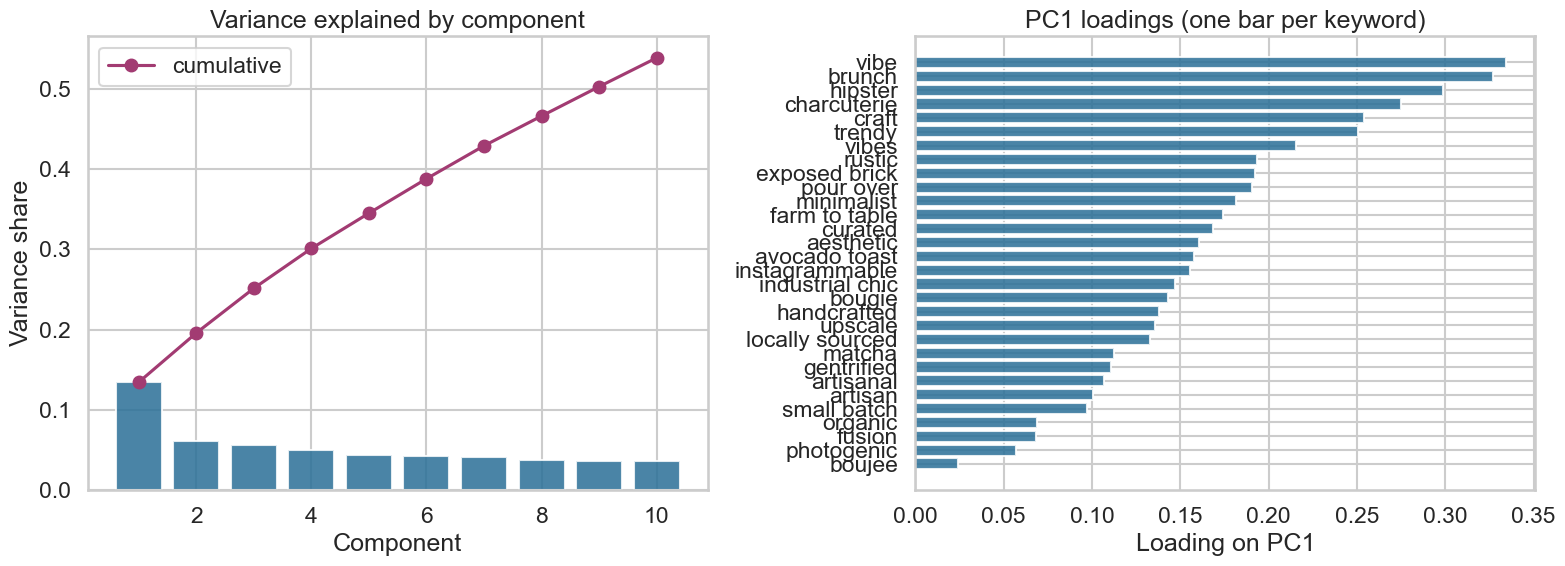

Top 5 loadings on PC1:
vibe           0.334
brunch         0.327
hipster        0.298
charcuterie    0.275
craft          0.254
dtype: float64

Bottom 5 loadings on PC1:
small batch    0.097
organic        0.069
fusion         0.069
photogenic     0.057
boujee         0.024
dtype: float64


In [3]:
# Variance share for the first 10 components and the loadings on PC1, side by side.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_show = 10
axes[0].bar(range(1, n_show + 1), pca.explained_variance_ratio_[:n_show],
            color="#2a6f97", alpha=0.85)
axes[0].plot(range(1, n_show + 1), np.cumsum(pca.explained_variance_ratio_[:n_show]),
             marker="o", color="#a23b72", label="cumulative")
axes[0].set_title("Variance explained by component")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Variance share")
axes[0].legend()

# Loadings on PC1, sorted from smallest to largest. We use the sign-aligned loadings
# from the previous cell so the chart matches the score column we'll regress on.
loadings = pd.Series(loadings_pc1, index=freq_cols).sort_values()
loadings.index = [c.replace("kw_", "").replace("_freq", "").replace("_", " ") for c in loadings.index]

axes[1].barh(loadings.index, loadings.values, color="#2a6f97", alpha=0.85)
axes[1].set_title("PC1 loadings (one bar per keyword)")
axes[1].set_xlabel("Loading on PC1")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

top_loadings = loadings.sort_values(ascending=False).head(5)
bottom_loadings = loadings.sort_values(ascending=False).tail(5)
print("Top 5 loadings on PC1:")
print(top_loadings.round(3))
print("\nBottom 5 loadings on PC1:")
print(bottom_loadings.round(3))


- PC1 explains about 13% of variance. That's the largest single component but not a dominant one, so the keyword space is genuinely high-dimensional.
- All 30 loadings sit on the same side of zero after the sign flip, so PC1 reads as "more vs less of the whole gentrifier vocabulary," not one word against another.
- Top contributors: `vibe`, `brunch`, `hipster`, `charcuterie`, `craft`. Bottom contributors (`boujee`, `photogenic`, `fusion`, `organic`, `small batch`) are all rare in the corpus.

### 6.3 Main regression

This is the preregistered model. We use HC3 robust standard errors (same as Phase 2) and compute a one-sided p-value, since the preregistered alternative is `beta > 0`.

In [4]:
# Sanity check on collinearity. The simple-average score is here only to see how much
# PC1 overlaps with the Phase 2 measure (it is not in the model).
predictor_corr = df[
    ["gentrify_pca_score", "gentrify_language_score", "avg_rent", "log_total_reviews"]
].corr().round(3)
display(predictor_corr)

h1_model = smf.ols(
    "next_year_rent_yoy_change ~ gentrify_pca_score "
    "+ avg_rent + log_total_reviews + C(metro) + C(year)",
    data=df,
).fit(cov_type="HC3")

# Drop the metro and year dummy rows so the table is readable.
h1_table = (
    h1_model.summary2()
    .tables[1]
    .loc[
        ["gentrify_pca_score", "avg_rent", "log_total_reviews"],
        ["Coef.", "Std.Err.", "z", "P>|z|", "[0.025", "0.975]"],
    ]
    .round(4)
)
display(h1_table)

# Preregistered test is one-sided (we predicted beta > 0).
beta = h1_model.params["gentrify_pca_score"]
se = h1_model.bse["gentrify_pca_score"]
t_stat = beta / se
p_one_sided = st.t.sf(t_stat, h1_model.df_resid)

print(f"\nN observations: {int(h1_model.nobs)}")
print(f"R-squared:      {h1_model.rsquared:.3f}")
print(f"\nH1 test on gentrify_pca_score (alternative: beta > 0)")
print(f"  beta = {beta:.4f}")
print(f"  SE   = {se:.4f}")
print(f"  t    = {t_stat:.3f}")
print(f"  one-sided p = {p_one_sided:.4f}")
print(f"  Reject H0 at alpha = 0.05? {'YES' if p_one_sided < 0.05 else 'NO'}")


,gentrify_pca_score,gentrify_language_score,avg_rent,log_total_reviews
gentrify_pca_score,1.000,0.931,0.054,0.343
gentrify_language_score,0.931,1.000,0.139,0.315
avg_rent,0.054,0.139,1.000,-0.157
log_total_reviews,0.343,0.315,-0.157,1.000


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
gentrify_pca_score,0.1366,0.0451,3.0309,0.0024,0.0482,0.2249
avg_rent,-0.0034,0.0004,-7.5161,0.0000,-0.0042,-0.0025
log_total_reviews,0.0985,0.0905,1.0881,0.2765,-0.0789,0.2759



N observations: 1113
R-squared:      0.664

H1 test on gentrify_pca_score (alternative: beta > 0)
  beta = 0.1366
  SE   = 0.0451
  t    = 3.031
  one-sided p = 0.0012
  Reject H0 at alpha = 0.05? YES


### 6.4 Interpretation: summarizing, predicting, oddities

gentrify_pca_score SD in panel: 2.011
Effect of +1 SD on PCA axis: about +0.275 percentage points of additional next-year rent growth, holding controls constant.

Model R-squared: 0.664
Residual RMSE:   2.851 percentage points


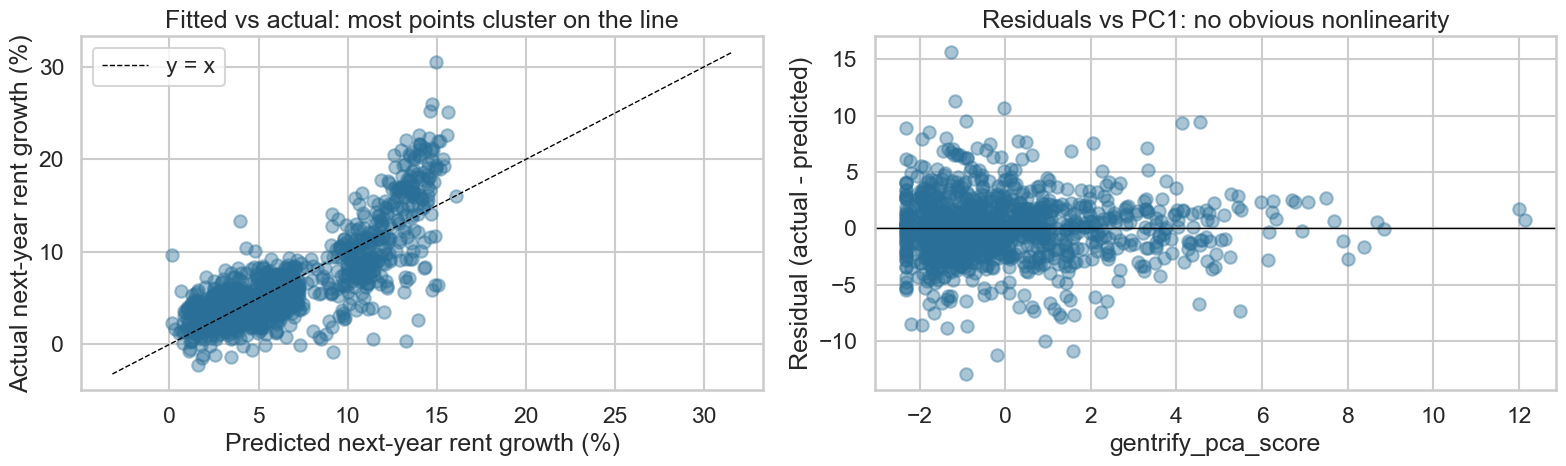


Five ZIP-years with the largest absolute residuals:


,postal_code,year,metro,next_year_rent_yoy_change,gentrify_pca_score,avg_rent,resid
0,33634,2021,Tampa Bay,30.566,-1.269,1335.467,15.601
1,33556,2021,Tampa Bay,0.331,-0.929,1830.425,-12.920
2,33756,2021,Tampa Bay,26.011,-1.167,1413.410,11.283
3,33637,2021,Tampa Bay,2.675,-0.204,1626.469,-11.268
4,46077,2021,Indianapolis,0.569,1.582,1472.220,-10.843


In [5]:
# Translate the coefficient into "effect per +1 SD on PCA axis" so the magnitude
# is concrete in percentage points.
pca_sd = df["gentrify_pca_score"].std()
effect_per_sd = h1_model.params["gentrify_pca_score"] * pca_sd
print(f"gentrify_pca_score SD in panel: {pca_sd:.3f}")
print(f"Effect of +1 SD on PCA axis: about {effect_per_sd:+.3f} percentage points "
      f"of additional next-year rent growth, holding controls constant.")

preds = h1_model.fittedvalues
resid = h1_model.resid
rmse = float(np.sqrt(np.mean(resid ** 2)))
print(f"\nModel R-squared: {h1_model.rsquared:.3f}")
print(f"Residual RMSE:   {rmse:.3f} percentage points")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(preds, df.loc[preds.index, "next_year_rent_yoy_change"], alpha=0.4, color="#2a6f97")
ymin = min(preds.min(), df["next_year_rent_yoy_change"].min()) - 1
ymax = max(preds.max(), df["next_year_rent_yoy_change"].max()) + 1
axes[0].plot([ymin, ymax], [ymin, ymax], color="black", linewidth=1, linestyle="--", label="y = x")
axes[0].set_xlabel("Predicted next-year rent growth (%)")
axes[0].set_ylabel("Actual next-year rent growth (%)")
axes[0].set_title("Fitted vs actual: most points cluster on the line")
axes[0].legend()

# Residuals vs PC1 to look for missing nonlinearity.
axes[1].scatter(df.loc[preds.index, "gentrify_pca_score"], resid, alpha=0.4, color="#2a6f97")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("gentrify_pca_score")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals vs PC1: no obvious nonlinearity")
plt.tight_layout()
plt.show()

# Where does the model miss the most?
df_with_resid = df.loc[preds.index].assign(resid=resid).copy()
worst = (
    df_with_resid.assign(abs_resid=df_with_resid["resid"].abs())
    .nlargest(5, "abs_resid")
    [["postal_code", "year", "metro", "next_year_rent_yoy_change",
      "gentrify_pca_score", "avg_rent", "resid"]]
    .round(3)
    .reset_index(drop=True)
)
print("\nFive ZIP-years with the largest absolute residuals:")
display(worst)


**Summarizing.** A +1 SD move on PC1 is associated with about +0.27 percentage points of additional next-year rent growth, holding metro, year, baseline rent, and review volume fixed. Panel mean rent growth is ~6.7 pp with an SD of ~4.9 pp, so the effect is real but small.

**Predicting.** R-squared is 0.66, almost all of which comes from the metro and year fixed effects (Phase 2 showed FEs alone hit ~0.64). PC1 adds a small but statistically reliable increment.

**Oddities.** Residuals vs PC1 are flat, no missing nonlinearity. The five largest residuals are 2020 and 2021 Tampa Bay ZIP-years, which is the COVID-era Sun Belt rent shock. Yelp signals had no chance of catching that.

### 6.5 Verdict on Hypothesis 1

- Preregistered alternative: `beta > 0` at alpha = 0.05.
- Estimated `beta` = 0.137 (HC3 SE = 0.045, t = 3.03).
- One-sided p = 0.0012, well below 0.05.

**We reject H0 in favor of H1.** A 1-SD increase on PC1 is associated with about a quarter percentage point of additional next-year rent growth at the ZIP level, after the controls. The result is observational so we're claiming association, not causation, but the sign and significance match the preregistered prediction.

## 7. Hypothesis 2 Analysis

To test this we estimate a linear regression predicting `next_year_rent_yoy_change` from `gentrify_density`, metro fixed effects, and the interaction between `gentrify_density` and metro:

`next_year_rent_yoy_change ~ gentrify_density * C(metro) + avg_rent + log_total_reviews + C(year)`

The interaction term `gentrify_density * C(metro)` allows each metro to have its own slope for the relationship between gentrification-associated business density and future rent growth.

We then conduct a joint F-test on all `gentrify_density x metro` interaction terms.

**Null hypothesis:** the interaction coefficients are jointly zero, meaning the relationship between gentrification density and next-year rent growth is the same across all metros.

**Alternative hypothesis:** at least one metro has a significantly different slope.

In [6]:
# Pull just the columns we need for the H2 model so it's easy to scan.
h2_vars = [
    "next_year_rent_yoy_change",
    "gentrify_density",
    "metro",
    "avg_rent",
    "log_total_reviews",
    "year",
]
h2_df = df[h2_vars].copy()
h2_df.head()


,next_year_rent_yoy_change,gentrify_density,metro,avg_rent,log_total_reviews,year
0,10.439205,0.221622,Philly MSA,1926.598740,6.968850,2021
1,3.400257,0.221622,Philly MSA,2127.720324,4.204693,2022
2,16.361993,0.108333,Philly MSA,1461.201615,5.713733,2021
3,13.309001,0.222222,Philly MSA,1461.589665,2.708050,2022
4,10.574048,0.235897,Philly MSA,1874.411145,6.903747,2021


In [7]:
# OLS with HC3 robust standard errors (same convention as Phase 2).
h2_model = smf.ols(
    "next_year_rent_yoy_change ~ gentrify_density * C(metro) + avg_rent + log_total_reviews + C(year)",
    data=h2_df,
).fit(cov_type="HC3")

print(h2_model.summary())


                                OLS Regression Results                               
Dep. Variable:     next_year_rent_yoy_change   R-squared:                       0.666
Model:                                   OLS   Adj. R-squared:                  0.661
Method:                        Least Squares   F-statistic:                     75.15
Date:                       Mon, 27 Apr 2026   Prob (F-statistic):          1.14e-176
Time:                               18:18:39   Log-Likelihood:                -2742.1
No. Observations:                       1113   AIC:                             5522.
Df Residuals:                           1094   BIC:                             5618.
Df Model:                                 18                                         
Covariance Type:                         HC3                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

In [8]:
# Joint F-test on all gentrify_density:C(metro) interaction terms.
interaction_terms = [
    term for term in h2_model.params.index
    if "gentrify_density:C(metro)" in term
]

hypotheses = " = 0, ".join(interaction_terms) + " = 0"
h2_f_test = h2_model.f_test(hypotheses)

f_stat = float(h2_f_test.fvalue)
p_value = float(h2_f_test.pvalue)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")


F-statistic: 2.8447
p-value: 0.0231
Reject the null hypothesis.


In [9]:
# Compact table of just the gentrify_density and metro-interaction coefficients.
h2_terms = [
    term for term in h2_model.params.index
    if term == "gentrify_density" or "gentrify_density:C(metro)" in term
]

h2_results = (
    h2_model.summary2()
    .tables[1]
    .loc[h2_terms, ["Coef.", "Std.Err.", "P>|z|"]]
    .rename(columns={"Coef.": "coef", "Std.Err.": "std_err", "P>|z|": "p_value"})
    .round(4)
)
display(h2_results)


,coef,std_err,p_value
gentrify_density,-0.4761,2.9560,0.8721
gentrify_density:C(metro)[T.Nashville],-3.7584,3.7180,0.3121
gentrify_density:C(metro)[T.New Orleans],-7.8929,7.1394,0.2689
gentrify_density:C(metro)[T.Philly MSA],-9.3414,4.0618,0.0215
gentrify_density:C(metro)[T.Tampa Bay],2.8009,3.6207,0.4392


**Interpretation.**
The joint F-test for the metro interaction terms was statistically significant, F = 2.8447, p = 0.0231. Because the p-value is below 0.05, we reject the null hypothesis that the interaction coefficients are jointly zero. This is evidence that the relationship between gentrification-associated business density and next-year rent growth varies across metros.

Indianapolis is the reference metro in this model. The main `gentrify_density` coefficient represents the estimated association between gentrification density and next-year rent growth in Indianapolis. This coefficient is negative but not statistically significant (coef = -0.4761, p = 0.8721).

The interaction terms show how each other metro's slope differs from Indianapolis. The largest difference is between Philly and Indianapolis. Philly MSA has a statistically significant negative interaction coefficient relative to Indianapolis (coef = -9.3414, p = 0.0215), meaning that in Philly, higher `gentrify_density` is associated with more negative next-year rent growth than in Indianapolis.

The interaction terms for Nashville, New Orleans, and Tampa Bay are not individually statistically significant, although the joint F-test indicates that the metro-specific slopes differ overall.

## 8. Hypothesis 3 Analysis

**Hypothesis.** ZIP-years in the top quartile of `gentrify_language_score` will have statistically higher next-year rent growth than those in the bottom quartile.

**Model.** OLS regression with quartile indicator variables (Q1 as the reference group):

`next_year_rent_yoy_change ~ C(language_quartile, Treatment('Q1')) + avg_rent + log_total_reviews + avg_price_range + C(metro) + C(year)`

**Null hypothesis.** The Q4 coefficient is zero. Top-quartile language ZIPs see no different rent growth than bottom-quartile ZIPs after controlling for metro, year, and baseline rent.

**Test.** Is the Q4 coefficient > 0 and statistically significant at alpha = 0.05? HC3 standard errors used for consistency with prior phases.

In [10]:
# Build the quartile assignment using equal-sized buckets on gentrify_language_score.
df["language_quartile"] = pd.qcut(
    df["gentrify_language_score"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
)

print("Observations per quartile:")
print(df["language_quartile"].value_counts().sort_index())

print("\nRaw mean rent growth by quartile (before controls):")
print(df.groupby("language_quartile", observed=True)["next_year_rent_yoy_change"].mean().round(3))


Observations per quartile:
language_quartile
Q1    280
Q2    277
Q3    278
Q4    278
Name: count, dtype: int64

Raw mean rent growth by quartile (before controls):


language_quartile
Q1    7.060
Q2    7.382
Q3    6.575
Q4    5.769
Name: next_year_rent_yoy_change, dtype: float64


In [11]:
# Main H3 model. Q1 as the reference category lets us read each higher quartile
# as the differential rent growth vs the lowest-language ZIPs.
# HC3 robust standard errors account for unequal variance across ZIP-years
model_h3 = smf.ols(
    "next_year_rent_yoy_change ~ C(language_quartile, Treatment('Q1')) + "
    "avg_rent + log_total_reviews + avg_price_range + C(metro) + C(year)",
    data=df,
).fit(cov_type="HC3")

print(model_h3.summary())

quartile_rows = [i for i in model_h3.params.index if "language_quartile" in i]
ci = model_h3.conf_int()

h3_results = pd.DataFrame({
    "Coef.":    model_h3.params[quartile_rows].round(4),
    "Std.Err.": model_h3.bse[quartile_rows].round(4),
    "t":        model_h3.tvalues[quartile_rows].round(4),
    "P>|t|":    model_h3.pvalues[quartile_rows].round(4),
    "[0.025":   ci.loc[quartile_rows, 0].round(4),
    "0.975]":   ci.loc[quartile_rows, 1].round(4),
})
h3_results.index = ["Q2 vs Q1", "Q3 vs Q1", "Q4 vs Q1"]
display(h3_results)

q4_coef = model_h3.params[quartile_rows[-1]]
q4_pval = model_h3.pvalues[quartile_rows[-1]]
print(f"\nQ4 vs Q1: coefficient = {q4_coef:.4f}, p-value = {q4_pval:.4f}")

if q4_pval < 0.05 and q4_coef > 0:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")


                                OLS Regression Results                               
Dep. Variable:     next_year_rent_yoy_change   R-squared:                       0.665
Model:                                   OLS   Adj. R-squared:                  0.659
Method:                        Least Squares   F-statistic:                     79.10
Date:                       Mon, 27 Apr 2026   Prob (F-statistic):          1.41e-176
Time:                               18:18:39   Log-Likelihood:                -2736.7
No. Observations:                       1110   AIC:                             5509.
Df Residuals:                           1092   BIC:                             5600.
Df Model:                                 17                                         
Covariance Type:                         HC3                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Q2 vs Q1,0.0848,0.2579,0.3288,0.7423,-0.4207,0.5902
Q3 vs Q1,0.4123,0.2770,1.4885,0.1366,-0.1306,0.9551
Q4 vs Q1,0.3741,0.2968,1.2605,0.2075,-0.2076,0.9557



Q4 vs Q1: coefficient = 0.3741, p-value = 0.2075
Fail to reject the null hypothesis.


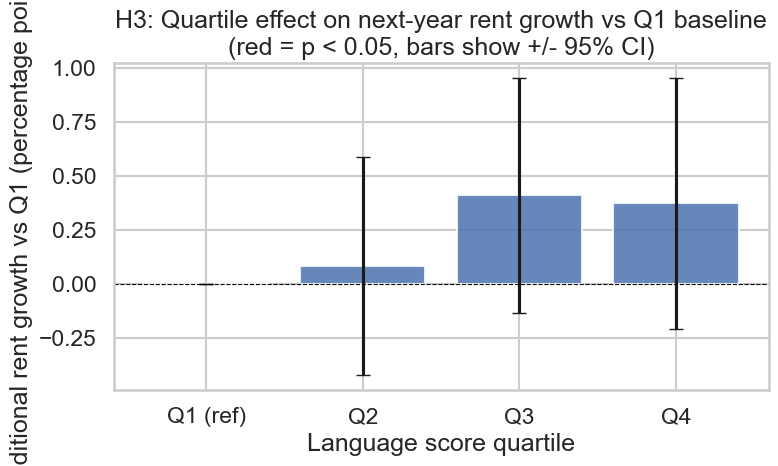

In [12]:
# Bar chart of each quartile's coefficient with 95% CIs, Q1 as the zero-baseline reference.
coefs  = [0] + [model_h3.params[r] for r in quartile_rows]
errors = [0] + [model_h3.bse[r] * 1.96 for r in quartile_rows]
labels = ["Q1 (ref)", "Q2", "Q3", "Q4"]
sig    = [False] + [model_h3.pvalues[r] < 0.05 for r in quartile_rows]

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ["gray" if i == 0 else ("#C44E52" if sig[i] else "#4C72B0") for i in range(4)]
ax.bar(labels, coefs, yerr=errors, color=bar_colors, capsize=5, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("H3: Quartile effect on next-year rent growth vs Q1 baseline\n(red = p < 0.05, bars show +/- 95% CI)")
ax.set_xlabel("Language score quartile")
ax.set_ylabel("Additional rent growth vs Q1 (percentage points)")
plt.tight_layout()
plt.show()


**Interpretation (Summarize, Predict, Oddities)**

**Summarize.** After controlling for baseline rent, review volume, price range, metro, and year, Q4 ZIP-years are associated with 0.37 more percentage points of rent growth than Q1 ZIP-years, but this is not statistically significant (p = 0.2075), so we fail to reject the null hypothesis. The Q4 coefficient is positive and in the predicted direction, but the evidence is not strong enough to conclude the effect is real at this sample size.

**Predict.** A ZIP-year in Q4 is predicted to see 0.37 percentage points more rent growth next year than a comparable Q1 ZIP-year in the same city and year, a modest difference relative to the overall mean rent growth of 6.7%.

**Oddities.** One thing worth flagging: before adding controls, Q4 actually had the lowest raw rent growth at 5.77%, lower than Q1 at 7.06%. That looks like it goes against our hypothesis. But this is because Q4 ZIP-years tend to be concentrated in cities or years that already had slower rent growth overall. Once we control for metro and year, we're comparing Q4 to Q1 within the same city and same year, and the coefficient flips positive (+0.37). So the direction is what we expected, it just doesn't cross the significance threshold. None of the quartile dummies ended up being individually significant.

## 9. Supplemental analysis

The preregistration is settled. This section is for sanity checks and follow-ups on Hypothesis 1.

### 9.1 PCA score vs simple averaged score

To check whether PCA is doing real work compared to the simpler equal-weight average score, we run the same regression both ways and put the estimates next to each other on a per-+1-SD basis.

In [13]:
# Same regression, swap the predictor for the Phase 2 simple average score.
avg_model = smf.ols(
    "next_year_rent_yoy_change ~ gentrify_language_score "
    "+ avg_rent + log_total_reviews + C(metro) + C(year)",
    data=df,
).fit(cov_type="HC3")


# Per +1 SD effect keeps the two estimates on the same scale, since the two scores
# have very different raw units.
def per_sd_row(model, var, label):
    sd = df[var].std()
    return {
        "predictor": label,
        "coef_per_unit": model.params[var],
        "predictor_SD": sd,
        "coef_per_+1_SD": model.params[var] * sd,
        "p_two_sided": model.pvalues[var],
        "R^2": model.rsquared,
        "N": int(model.nobs),
    }


compare = pd.DataFrame([
    per_sd_row(avg_model, "gentrify_language_score", "Phase 2 simple average score"),
    per_sd_row(h1_model, "gentrify_pca_score", "Phase 4 PCA score (PC1)"),
]).round(4)
display(compare)


,predictor,coef_per_unit,predictor_SD,coef_per_+1_SD,p_two_sided,R^2,N
0,Phase 2 simple average score,118.7507,0.0020,0.2408,0.0074,0.6636,1113
1,Phase 4 PCA score (PC1),0.1366,2.0108,0.2746,0.0024,0.6642,1113


- Both scores are positive and statistically significant in the same fully controlled model. The simple average works.
- PC1 gives a slightly larger per-+1-SD effect (~0.27 vs ~0.24 pp) and a smaller p-value. PCA weights keywords by their actual covariance structure rather than equal-weighting noisy words alongside informative ones.
- The big-picture conclusion doesn't depend on which score we use; the simpler equal-weight measure leads to the same answer.

### 9.2 Robustness: ZIP-years with at least 100 reviews

Phase 2 raised the concern that thinly reviewed ZIP-years might be driving the signal. We refit the H1 model on the high-volume subset.

In [14]:
# Same regression, restricted to ZIP-years with at least 100 reviews.
# This trades sample size (1,113 -> 897) for less measurement noise on keyword frequencies.
high_volume_df = df[df["total_reviews"] >= 100].copy()

h1_model_hv = smf.ols(
    "next_year_rent_yoy_change ~ gentrify_pca_score "
    "+ avg_rent + log_total_reviews + C(metro) + C(year)",
    data=high_volume_df,
).fit(cov_type="HC3")

# One-sided p value, same convention as the main test.
beta_hv = h1_model_hv.params["gentrify_pca_score"]
se_hv = h1_model_hv.bse["gentrify_pca_score"]
p_one_hv = st.t.sf(beta_hv / se_hv, h1_model_hv.df_resid)

robust = pd.DataFrame({
    f"full sample (N={int(h1_model.nobs)})": {
        "coef_pca": h1_model.params["gentrify_pca_score"],
        "SE_HC3": h1_model.bse["gentrify_pca_score"],
        "p_two_sided": h1_model.pvalues["gentrify_pca_score"],
        "p_one_sided": st.t.sf(
            h1_model.params["gentrify_pca_score"] / h1_model.bse["gentrify_pca_score"],
            h1_model.df_resid,
        ),
        "R^2": h1_model.rsquared,
    },
    f"reviews >= 100 (N={int(h1_model_hv.nobs)})": {
        "coef_pca": beta_hv,
        "SE_HC3": se_hv,
        "p_two_sided": h1_model_hv.pvalues["gentrify_pca_score"],
        "p_one_sided": p_one_hv,
        "R^2": h1_model_hv.rsquared,
    },
}).round(4)
display(robust)


,full sample (N=1113),reviews >= 100 (N=897)
coef_pca,0.1366,0.1281
SE_HC3,0.0451,0.0571
p_two_sided,0.0024,0.0248
p_one_sided,0.0012,0.0125
R^2,0.6642,0.6885


The PC1 coefficient stays positive, similar in magnitude, and significant at alpha = 0.05 (one-sided). The H1 result isn't an artifact of low-volume rows where keyword frequencies are noisy.

### 9.3 Coefficient stability across specifications

Phase 2 had a memorable finding: the language coefficient flipped sign once year fixed effects were added, because of the COVID-era rent shock. We expect PC1 to behave the same way.

,spec,coef,SE_HC3,p_two_sided,R^2
0,(1) PC1 only,-0.2170,0.0630,0.0006,0.0079
1,(2) + baseline rent + log reviews,-0.3098,0.0681,0.0000,0.0182
2,(3) + Metro FE,-0.2033,0.0648,0.0017,0.1035
3,(4) + Metro + Year FE [preregistered],0.1366,0.0451,0.0024,0.6642


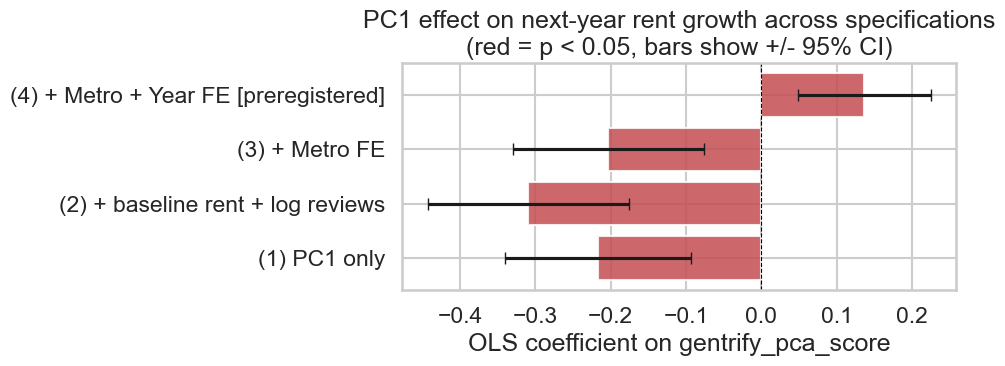

In [15]:
# Stepwise specification ladder. The point is not to pick a final model
# (we already preregistered model 4). The point is to show how sensitive the PC1 coefficient
# is to which controls are included, especially the year fixed effect.
specs = {
    "(1) PC1 only": "next_year_rent_yoy_change ~ gentrify_pca_score",
    "(2) + baseline rent + log reviews": (
        "next_year_rent_yoy_change ~ gentrify_pca_score "
        "+ avg_rent + log_total_reviews"
    ),
    "(3) + Metro FE": (
        "next_year_rent_yoy_change ~ gentrify_pca_score "
        "+ avg_rent + log_total_reviews + C(metro)"
    ),
    "(4) + Metro + Year FE [preregistered]": (
        "next_year_rent_yoy_change ~ gentrify_pca_score "
        "+ avg_rent + log_total_reviews + C(metro) + C(year)"
    ),
}

rows = []
for name, formula in specs.items():
    m = smf.ols(formula, data=df).fit(cov_type="HC3")
    rows.append({
        "spec": name,
        "coef": m.params["gentrify_pca_score"],
        "SE_HC3": m.bse["gentrify_pca_score"],
        "p_two_sided": m.pvalues["gentrify_pca_score"],
        "R^2": m.rsquared,
    })

stability = pd.DataFrame(rows).round(4)
display(stability)

# Forest-style plot, color-coded by significance, same style as Phase 2 section 6.5.
fig, ax = plt.subplots(figsize=(10, 4))
errs = stability["SE_HC3"].values * 1.96
colors = ["#C44E52" if p < 0.05 else "gray" for p in stability["p_two_sided"]]
ax.barh(stability["spec"], stability["coef"], xerr=errs, color=colors, capsize=4, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("OLS coefficient on gentrify_pca_score")
ax.set_title(
    "PC1 effect on next-year rent growth across specifications\n"
    "(red = p < 0.05, bars show +/- 95% CI)"
)
plt.tight_layout()
plt.show()


The PCA coefficient is *negative* in specs (1) through (3) and *positive* in spec (4) once year fixed effects are added. Same sign-flip Phase 2 reported for the simple average score. The explanation: 2020 and 2021 had a large COVID-era rent spike alongside a small dip in keyword frequency. Without year fixed effects, the regression is fooled by that pattern. Once year FEs partial out the common time shock, the within-year relationship comes through positive. That's the H1 result.

This is also why the preregistration explicitly included year fixed effects: we already knew from Phase 2 that the within-year comparison is the right one for our research question.

## 10. Conclusions

- **RQ1 / H1.** Yes. A PCA-based gentrification language score is a statistically significant positive predictor of next-year rent growth at the ZIP level, after controlling for baseline rent, review volume, metro, and year. A +1 SD on the PCA axis corresponds to about +0.27 pp of additional next-year rent growth (one-sided p = 0.0012). The result holds when we drop thinly reviewed ZIP-years, and the simple-average score points the same way.
- **RQ2 / H2.** Yes. The joint F-test on the `gentrify_density x metro` interaction terms is statistically significant (F = 2.85, p = 0.0231), so we reject the null that the metro slopes are jointly equal. The relationship between gentrification-associated business density and next-year rent growth varies across the five metros. The largest contrast is Philly MSA versus Indianapolis, where Philly's slope is significantly more negative.
- **RQ3 / H3.** No. The Q4 vs Q1 coefficient on `gentrify_language_score` quartiles is positive (+0.37 pp) and in the predicted direction, but it is not statistically significant (p = 0.2075), so we fail to reject the null. None of the quartile dummies were individually significant. Interestingly, the raw means before controls put Q4 *below* Q1, and the controls flip the sign positive once metro and year are partialled out.

Across the three hypotheses, the cleanest result is H1. After the controls, ZIP-years that score higher on a data-driven gentrifier vocabulary axis tend to see modestly higher rent growth in the following year. H2 adds nuance: business-composition signals don't have a single nationwide slope, which is a useful caveat for anyone trying to apply a one-size-fits-all gentrification metric across metros. H3 falls short of significance, which we read as a sample-size and noise issue rather than evidence against H1. Yelp text is worth including alongside traditional rent forecasting inputs, not because it's a strong predictor on its own, but because it's free, public, updates in near-real time, and adds incremental signal over what fixed effects and baseline rent already capture.

## 11. Limitations

- **Geographic concentration.** Five metros (~238 ZIP codes, 2015 to 2022) chosen for Yelp data quality. Results may not generalize to smaller cities, rural areas, or metros with different gentrification dynamics. Tampa Bay had a particularly large COVID-era rent shock that may pull on the average effect even with year fixed effects.
- **Static business features.** Yelp business metadata is a snapshot with no opening-date field, so `gentrify_density` doesn't vary over time within a ZIP. Mainly affects H2, but indirectly affects H1 too.
- **Reviewer demographic bias.** Yelp reviewers skew younger, urban, and tech-savvy. A rising PC1 score could reflect a shift in *who reviews on Yelp* rather than a shift in the neighborhood. This is a real harm: if PC1 is a better proxy for "in-migration of Yelp-active demographics" than for neighborhood change broadly, publishing it as a gentrification indicator could end up tracking and amplifying that demographic shift.
- **Keyword noise.** Hand-curated terms like `craft` and `rustic` show up in non-gentrification contexts. PCA mitigates this by down-weighting keywords whose variance doesn't co-move with the dominant axis, but it can't fix fundamentally ambiguous words.
- **PC1 isn't a clean construct.** PC1 explains only ~13% of joint variance, so 87% lives in higher components we ignore. If important gentrification signal lives in PC2 or PC3, we miss it.
- **PCA wasn't strictly necessary.** The simple-average score gave the same conclusion. PCA gave a slightly cleaner estimate, but we shouldn't overclaim that the methodology choice was load-bearing.
- **ZORI smoothing and coverage gaps.** Zillow's smoothing can lag detection of rapid rent changes. Thinly listed ZIP codes are excluded from ZORI, biasing our sample toward larger or more commercially active ZIPs.
- **Observational design.** All findings are associational. Without randomization or a quasi-experimental design, we can't establish that Yelp signals *cause* rent changes rather than co-occur with them.

**Potential harms and data gaps.** The headline harm is misuse. A positive Yelp-language signal could be marketed as a "gentrification predictor" by real estate platforms, and that framing risks accelerating the dynamic we're studying. The ZIP-level grain is also coarse. Real gentrification often operates at the block-group level, so policy decisions made off ZIP-level Yelp scores would inevitably mis-target both winners and losers.

## 12. Acknowledgements and bibliography

### Data sources
- **Yelp Open Dataset.** Yelp Inc. https://business.yelp.com/data/resources/open-dataset/.
- **Zillow Observed Rent Index (ZORI), Smoothed All Homes Plus Multifamily.** Zillow Group, Inc. https://www.zillow.com/research/data/.

### Tools and libraries
Python 3, `pandas`, `numpy`, `scikit-learn`, `statsmodels`, `scipy.stats`, `seaborn`, `matplotlib`, `IPython.display`, Jupyter Notebook.

### References
- Glaeser, E. L., Kim, H., & Luca, M. (2018). *Nowcasting Gentrification: Using Yelp Data to Quantify Neighborhood Change.* American Economic Association Papers and Proceedings, 108, 77-82.
- Jolliffe, I. T. (2002). *Principal Component Analysis.* Springer Series in Statistics, 2nd edition.
- Ley, D. (1994). *Gentrification and the Politics of the New Middle Class.* Environment and Planning D, 12(1), 53-74.
- Papachristos, A. V., Smith, C. M., Scherer, M. L., & Fugiero, M. A. (2011). *More Coffee, Less Crime? The Relationship between Gentrification and Neighborhood Crime Rates in Chicago, 1991 to 2005.* City & Community, 10(3), 215-240.
- Zukin, S., Trujillo, V., Frase, P., Jackson, D., Recuber, T., & Walker, A. (2009). *New Retail Capital and Neighborhood Change: Boutiques and Gentrification in New York City.* City & Community, 8(1), 47-64.
- Zukin, S. (2010). *Naked City: The Death and Life of Authentic Urban Places.* Oxford University Press.

### Acknowledgements
Thanks to the CS/INFO 5304 teaching staff for Phase 2 and Phase 3 feedback.